---

## **Instructor Notes – What’s Happening in This Notebook**

### Experiment Title:

**Explore Visual Classification using k-NN Algorithm**

---

### **What Is This Experiment About?**

This experiment helps students visually understand how a **k-Nearest Neighbors (k-NN)** algorithm works for classification tasks. We used the **Iris flower dataset**, which is a famous beginner dataset with 3 types of flowers.

Students will:

* See how the algorithm separates classes in a 2D space
* Add their own test point (new data) and see how its class is predicted
* Observe how changing the value of `k` affects prediction accuracy and behavior

This is a **low-code, high-visual** experiment designed to **teach core ML intuition** (e.g., bias vs variance).

---

### **About the Dataset: Iris Flower Dataset**

* This dataset contains measurements of **150 flowers**, divided into **3 species**:

  * `Setosa`
  * `Versicolor`
  * `Virginica`

* Each flower sample has:

  * Sepal length
  * Sepal width
  * Petal length
  * Petal width

* We only used **petal length and petal width** for plotting and predictions, because these features offer **better visual class separation**.

#### Suggested Visual Reference:

![Iris Dataset 2D Scatter Example](https://upload.wikimedia.org/wikipedia/commons/5/56/Iris_dataset_scatterplot.svg)

![# species visualisation](https://miro.medium.com/v2/resize:fit:1100/format:webp/0*9ut2vvn6drS53dSL.png)

![Sepal vs Petal](https://www.ashokcharan.com/Marketing-Analytics/images/sma-py-5.jpg)

---

### **Concept of k-NN (k-Nearest Neighbors)**

* k-NN is a **supervised learning** algorithm
* It stores the entire dataset and **predicts the class of a new sample** by looking at the *‘k’ closest samples* (neighbors) around it
* The predicted class is the **majority class among those k neighbors**

#### Example:

If `k = 3`, and 2 out of 3 closest points are Setosa, then the new point will be classified as **Setosa**

---

### **What Was Done Step-by-Step**

#### **STEP 1: Import Libraries**

All necessary libraries like NumPy, pandas, matplotlib, and sklearn were imported.

#### **STEP 2: Load the Dataset**

The Iris dataset was loaded using `load_iris(as_frame=True)` and converted into a pandas DataFrame.

#### **STEP 3: Visualize Clusters**

A scatter plot was created using **petal length vs petal width** with different colors representing the three classes.

#### **STEP 4: Student Task – Add a Test Point**

A new data point (e.g., `[4.5, 1.5]`) was added. This simulates a *new flower measurement*.

#### **STEP 5: Train and Predict Using k-NN**

The model was trained using different values of `k` (e.g., 1, 3, 5, 7). For each `k`, the class of the new test point was predicted and printed.

#### **STEP 6: Visualize the Test Point**

The test point was plotted along with the training data so students could **see** where it falls and why it was classified that way.

---

### **Learning Takeaways for Instructors**

* Small `k` → high variance (can overfit)
* Large `k` → high bias (can underfit)
* Visual tools help students understand **decision boundaries** intuitively
* The Iris dataset is perfectly separable in this 2D space, making it ideal for this demo

---

### Suggestion for Extension

Ask fast-finishers to:

* Change the input features to sepal width & length
* Try predicting two test points at once
* Plot decision boundaries using `mlxtend.plotting` or seaborn pairplots

---

In [1]:
# STEP 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

print("Libraries loaded.")

Libraries loaded.


In [2]:
# STEP 2: Load and Preview the Iris Dataset
iris = load_iris(as_frame=True)
df = iris.frame

print("Sample of the dataset:")
print(df.head())


Sample of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


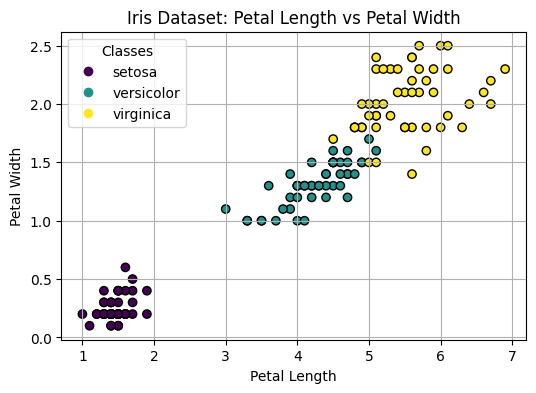

In [3]:
# STEP 3: Plot the Data to Visualize Clusters
plt.figure(figsize=(6, 4))
scatter = plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    c=df["target"],
    cmap='viridis',
    edgecolor='k'
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset: Petal Length vs Petal Width")

# FIXED: Add legend using scatter handles + labels mapped manually
legend_labels = iris.target_names
handles, _ = scatter.legend_elements()
plt.legend(handles, legend_labels, title="Classes")

plt.grid(True)
plt.show()



In [4]:
# STEP 4: ✍️ Student Task – Add Your Own Test Point Below
# Try changing the values and see how the prediction changes
test_point = pd.DataFrame([[4.5, 1.5]], columns=["petal length (cm)", "petal width (cm)"])

In [5]:
# STEP 5: Experiment with Different k values
for k in [1, 3, 5, 7]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(df[["petal length (cm)", "petal width (cm)"]], df["target"])
    pred = model.predict(test_point)
    print(f"For k = {k}, predicted class: {iris.target_names[pred[0]]}")

For k = 1, predicted class: versicolor
For k = 3, predicted class: versicolor
For k = 5, predicted class: versicolor
For k = 7, predicted class: versicolor


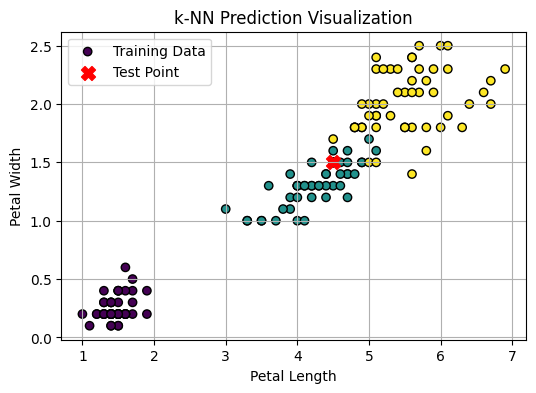

In [6]:
# STEP 6: Student Task – Visualize the Test Point with Training Data
plt.figure(figsize=(6, 4))

# Plot all the training data
plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    c=df["target"],
    cmap='viridis',
    edgecolor='k',
    label='Training Data'
)

# Plot the test point correctly
plt.scatter(
    test_point["petal length (cm)"].values[0],
    test_point["petal width (cm)"].values[0],
    c='red',
    s=100,
    marker='X',
    label='Test Point'
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("k-NN Prediction Visualization")
plt.legend()
plt.grid(True)
plt.show()

